In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv
/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv


## Step 1 – Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

## Step 2 – List of files

In [37]:
import os
for dirname,_,filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print(" ",filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/kartik2112
/kaggle/input/datasets/kartik2112/fraud-detection
  fraudTest.csv
  fraudTrain.csv


## Step 3: Load the Dataset

In [38]:
train_df = pd.read_csv(
    "/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv"
)

## Step 4: Exploratory Data Analysis (EDA)

In [39]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [40]:
train_df.shape

(1296675, 23)

In [41]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [42]:
train_df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [43]:
train_df.duplicated().sum()

np.int64(0)

In [44]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


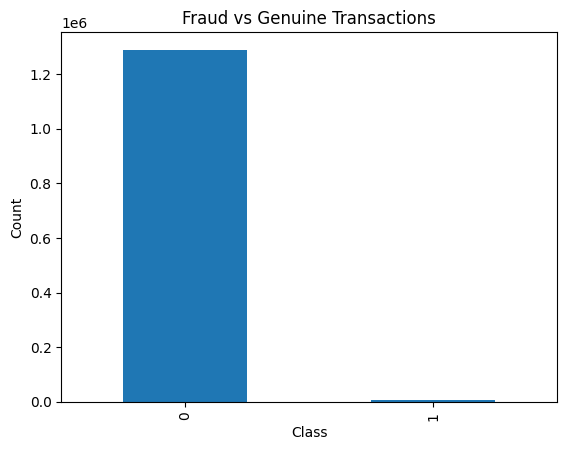

In [45]:
train_df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [46]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

## Step 5: Drop Unnecessary Columns

In [47]:
columns_to_drop = [
    "Unnamed: 0",
    "trans_num",
    "cc_num",
    "first",
    "last",
    "street"
]

train_df = train_df.drop(columns=columns_to_drop, errors="ignore")
test_df = test_df.drop(columns=columns_to_drop, errors="ignore")
print(train_df.columns.tolist())

['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## Step 6: Encode Categorical Features

In [48]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = train_df.select_dtypes(include="object").columns

for col in categorical_columns:
    encoder = LabelEncoder()

    # Combine train and test values
    combined = pd.concat([train_df[col], test_df[col]], axis=0)

    # Learn all categories
    encoder.fit(combined)

    # Transform both datasets
    train_df[col] = encoder.transform(train_df[col])
    test_df[col] = encoder.transform(test_df[col])

In [49]:
train_df = train_df.drop(columns=["trans_date_trans_time"], errors="ignore")
test_df = test_df.drop(columns=["trans_date_trans_time"], errors="ignore")

In [50]:
train_df = train_df.drop(columns=["dob"], errors="ignore")
test_df = test_df.drop(columns=["dob"], errors="ignore")

In [51]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

## Step 8: Train the Logistic Regression Model

In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [53]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


## Step 9: Make Predictions

In [57]:
y_pred = model.predict(X_test)

## Step 10: Calculate Accuracy

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9955139198047934


## Step 11: Classification Report

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



## step 12:Bar Graph

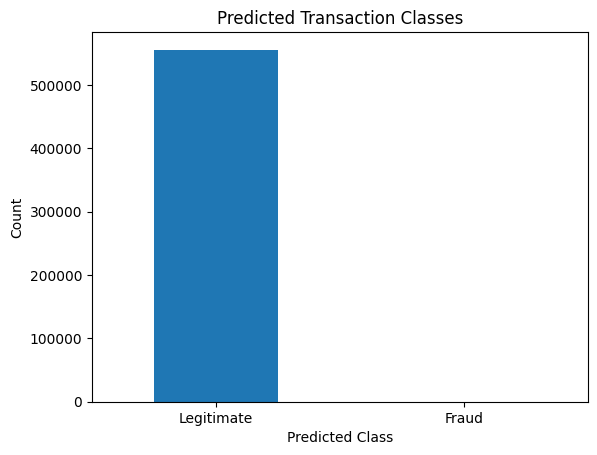

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

pd.Series(y_pred).value_counts().plot(kind="bar")

plt.title("Predicted Transaction Classes")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)

plt.show()

## Step 13: Display Some Predictions

In [61]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


## Step 14: Test with a Sample Transaction

In [64]:
sample = X_test.iloc[[5]]

prediction = model.predict(sample)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("⚠️ Fraudulent Transaction")
else:
    print("✅ Legitimate Transaction")

Prediction: [0]
✅ Legitimate Transaction


#  Conclusion

In this project, a Credit Card Fraud Detection model was developed using Logistic Regression.

The dataset was loaded and explored to understand transaction details. The data was preprocessed by removing unnecessary columns and encoding categorical features into numerical values. The dataset was then divided into training and testing sets.

A Logistic Regression model was trained to classify transactions as fraudulent or legitimate. The model's performance was evaluated using accuracy, a classification report, and graphical visualizations.

This project demonstrates how machine learning can assist financial institutions in identifying suspicious transactions and reducing fraud.